In [1]:
#Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
#Step 2: Load Dataset
# Load dataset
df = pd.read_csv("1_boston_housing.csv")

# Remove quotes from column names (important for your dataset)
df.columns = df.columns.str.replace('"', '')

# Display first 5 rows
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [3]:
#Step 3: Split Features and Target
X = df.drop("MEDV", axis=1)   # Features
y = df["MEDV"]                # Target

print(X.shape, y.shape)

(506, 13) (506,)


In [4]:
#Step 4: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
#Step 5: Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
# Two things happen:

# fit() → learns mean & std from training data
# transform() → scales the data
X_test = scaler.transform(X_test)

In [6]:
model = Sequential()
# It creates a simple neural network (linear regression model) and trains it to predict values.

# model.add(Dense(1, input_shape=(X_train.shape[1],), activation='linear'))
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))
# This is a Artificial Neural Network layer
# What it means:
# Dense(1) → 1 output neuron
# input_shape=(X_train.shape[1],) → number of input features
# activation='linear' → no transformation

#  This is basically:
#  Linear Regression using Neural Network

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)
#  Optimizer
# adam → adjusts weights efficiently



history = model.fit(
    X_train, y_train,
    epochs=200,
    validation_split=0.2,
    verbose=1
)
# Model trains 100 times over dataset
#  validation_split=0.05
#  Uses 5% of training data for validation
#  verbose=1
#  Shows training progress

d:\Anaconda\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 594.0813 - mae: 22.3795 - val_loss: 520.9629 - val_mae: 21.2322
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 563.2613 - mae: 21.6875 - val_loss: 486.7899 - val_mae: 20.4371
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 518.0686 - mae: 20.6652 - val_loss: 437.1764 - val_mae: 19.2298
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 454.1586 - mae: 19.1207 - val_loss: 365.9214 - val_mae: 17.3633
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 365.4813 - mae: 16.8329 - val_loss: 273.4082 - val_mae: 14.7658
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 257.5418 - mae: 13.7245 - val_loss: 168.7243 - val_mae: 11.2039
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 148.8522 - mae: 9.8866 - val_loss: 83.4824 - val_mae: 7.0900
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 83.9236 - mae: 7.3170 - val_loss: 52.7234 - val_mae: 5.2296
Epoch 9/200
11/

In [8]:
# Step 6: Build Deep Neural Network
# model = Sequential()

# # Single neuron → behaves like linear regression
# model.add(Dense(1, input_shape=(X_train.shape[1],), activation='linear'))
# # This is a Dense Layer
# # Meaning:
# # Dense(1) → only 1 neuron (output)
# # input_shape → number of input features
# # activation='linear' → no activation

# model.compile(
#     optimizer='adam',
#     loss='mse',
#     metrics=['mae']
# )

model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# Components:
# Adam Optimizer → updates weights
# mse → Mean Squared Error (loss)
# mae → Mean Absolute Error (metric)

model.summary()

# Parameters = (inputs × neurons) + bias
# =(13*1)+1=14

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
#Step 7: Train Model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)
# Feeds data to the model
# Adjusts weights using backpropagation
# Minimizes error (loss)
# Data is split into small groups of 16
# 20% of training data used for validation
# Helps check if model is overfitting
# Not used for training, only evaluation
# verbose=1
# |
#  Shows training progress like:

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 571.4496 - mae: 21.9527 - val_loss: 481.1225 - val_mae: 20.3681
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 482.0351 - mae: 19.8574 - val_loss: 362.4418 - val_mae: 17.3696
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 313.8812 - mae: 15.2356 - val_loss: 165.2976 - val_mae: 10.9343
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 131.0262 - mae: 9.2277 - val_loss: 57.9510 - val_mae: 5.6190
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 77.8195 - mae: 7.0232 - val_loss: 36.2338 - val_mae: 4.3328
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 47.9483 - mae: 5.3926 - val_loss: 25.9398 - val_mae: 3.5951
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 32.4800 - mae: 4.3228 - val_loss: 23.5057 - val_mae: 3.4626
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 24.6828 - mae: 3.7477 - val_loss: 22.2578 - val_mae: 3.4026
Epoch 9/100
21/21 ━━━━━━━━━━━━━━━━

In [10]:
#Step 8: Evaluate Model
loss, mae = model.evaluate(X_test, y_test)

print("Test Loss (MSE):", loss)
print("Test MAE:", mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 11.2771 - mae: 2.2081
Test Loss (MSE): 11.277121543884277
Test MAE: 2.208070993423462


In [11]:
#Step 9: Predictions
y_pred = model.predict(X_test)

# Compare actual vs predicted
for i in range(5):
    print(f"Actual: {y_test.iloc[i]:.2f} | Predicted: {y_pred[i][0]:.2f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Actual: 23.60 | Predicted: 27.36
Actual: 32.40 | Predicted: 34.64
Actual: 13.60 | Predicted: 15.84
Actual: 22.80 | Predicted: 24.34
Actual: 16.10 | Predicted: 16.33


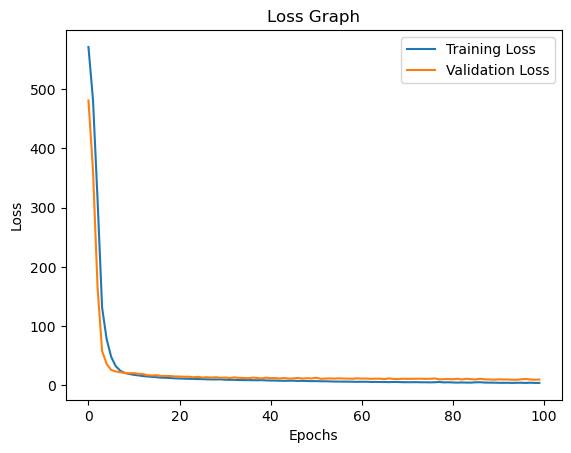

In [12]:
#Step 10: Plot Training Graphs
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Graph")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()